# Check which runs and which part of runs have failed

In [9]:
import pandas as pd
import numpy as np
import natsort
import os
import importlib
import yaml
import scipy
import scipy.stats
import plotnine as p9


import plots
import plotninesettings as p9conf
parsed = importlib.import_module("parse-parsed")

### Preprocessing functions

In [2]:
def labeler_gnb_version(x):
    if x == "release_24_04":
        return "srsRAN 24.04"
    elif x == "release_24_10":
        return "srsRAN 24.10"
    elif x == "v2.1.0":
        return "OAI 2.1.0"
    elif x == "v2.2.0":
        return "OAI 2.2.0"
    else:
        return x

def add_labels(df: pd.DataFrame):
    if "gnb_version__version" in df.columns:
        df["gnb_version_label"] = df["gnb_version__version"].apply(labeler_gnb_version)
    if "traffic_config__rate" in df.columns:
        df["traffic_config__rate_lbl"] = pd.Categorical(df["traffic_config__rate"], ordered=True, categories= natsort.natsorted(df["traffic_config__rate"].unique()))
        df["traffic_config__rate_int"] = df["traffic_config__rate"].apply(lambda x: int(x[:-1]) if x.endswith("M") else 0)
    if "direction" in df.columns:
        df["direction"] = df["direction"].apply(lambda x : x.upper())
    if "tdd_config__tdd_ratio" in df.columns:
        df["tdd_ratio_label"]=df["tdd_config__tdd_ratio"].apply(lambda x: f"{x}:1")
        df['tdd_ratio_label'] = pd.Categorical(df['tdd_ratio_label'], ordered=True, categories= natsort.natsorted(df['tdd_ratio_label'].unique()))
    if "tdd_config__tdd_period" in df.columns:
        df["tdd_period_label"]=df["tdd_config__tdd_period"].apply(lambda x: f"{x} slots")
        df['tdd_period_label'] = pd.Categorical(df['tdd_period_label'], ordered=True, categories= natsort.natsorted(df['tdd_period_label'].unique()))
    if "run" in df.columns:
        df['run'] = pd.Categorical(df['run'], ordered=True, categories= natsort.natsorted(df['run'].unique()))
    if "tdd_config__tdd_ratio" in df.columns and "tdd_config__tdd_period" in df.columns:
        df["tdd_label"]="Dl/Ul: " + df["tdd_config__tdd_ratio"].astype(str) + "; #: " + df["tdd_config__tdd_period"].astype(str)
        df['tdd_label'] = pd.Categorical(df['tdd_label'], ordered=True, categories= natsort.natsorted(df['tdd_label'].unique()))
    return df

### Data import

In [3]:
# df = pd.read_parquet("/storage/test_new_tdd/all_runs.parquet")
df = pd.read_parquet("/storage/test_new_tdd_fixedsrs/all_runs.parquet")
df = add_labels(df)

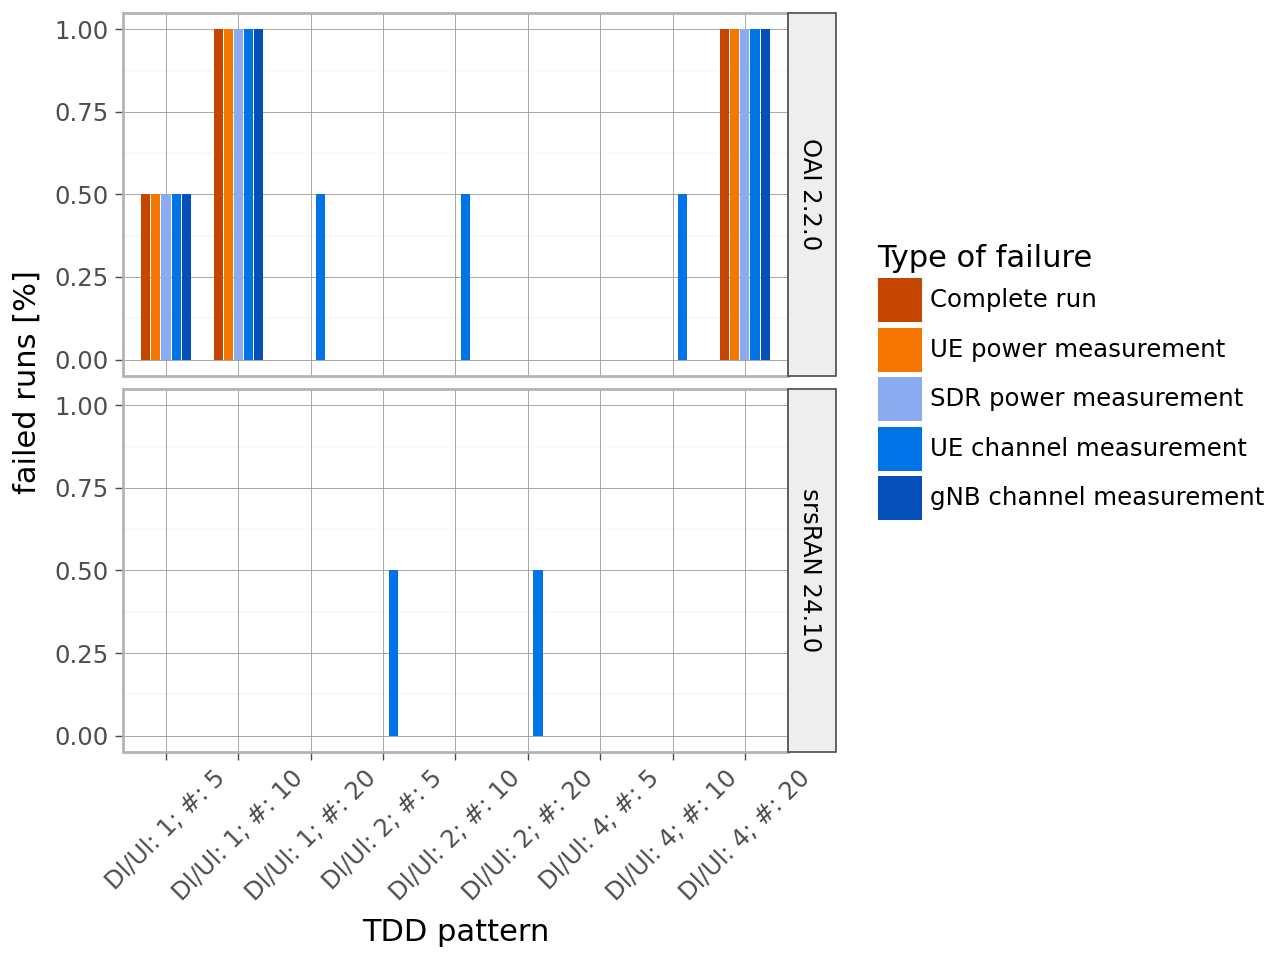

In [15]:

df_plot = df.groupby(["gnb_version_label","traffic_config__direction","tdd_label"], observed=True).agg( {
    "failed_run":["mean"], "ue_power_failed":["mean"], "sdr_power_failed":["mean"], "ue_channelmetrics_failed":["mean"], "gnb_channelmetrics_failed":["mean"]
     } )
df_plot.columns = list(map(lambda x: '__agg__'.join(filter(None,x)), df_plot.columns.values))
df_plot = df_plot.reset_index()

def relabel_value_vars(x):
    if x == "failed_run__agg__mean":
        return "Complete run"
    if x == "ue_power_failed__agg__mean":
        return "UE power measurement"
    if x == "sdr_power_failed__agg__mean":
        return "SDR power measurement"
    if x == "ue_channelmetrics_failed__agg__mean":
        return "UE channel measurement"
    if x == "gnb_channelmetrics_failed__agg__mean":
        return "gNB channel measurement"
failure_value_vars = ["failed_run__agg__mean","ue_power_failed__agg__mean","sdr_power_failed__agg__mean","ue_channelmetrics_failed__agg__mean","gnb_channelmetrics_failed__agg__mean"]
df_plot_agg = df_plot.melt(
        id_vars=["gnb_version_label","traffic_config__direction","tdd_label"],
        value_vars=failure_value_vars,
        value_name="failures", var_name="type_of_failure")
df_plot_agg["type_of_failure"] = pd.Categorical(df_plot_agg["type_of_failure"] , ordered=True, categories=failure_value_vars)
df_plot_agg["type_of_failure"] = df_plot_agg["type_of_failure"].apply(relabel_value_vars)


plot_agg = (p9.ggplot(df_plot_agg)
        + p9.facet_grid(rows=["gnb_version_label"], scales="free_y" )
        + p9.aes(y="failures",
                 x="tdd_label", fill="type_of_failure")
        + p9.geom_col(width=p9conf.WIDTH, position=p9.position_dodge2())
        + p9.ylim((0.0, 1.0))
        + p9.labs(y="failed runs [%]", x="TDD pattern", color="", fill="Type of failure", linetype="")
        + p9.scale_color_manual(p9conf.COLOR_MAP_EXTRACTOR(3), drop=True)
        + p9.scale_fill_manual(p9conf.COLORS, drop=True)
        + p9conf.GLOBAL_THEME()
        )
plot_agg.show()
